# Phase 1: Delay EDA

Starting point for exploring `v_stop_delays` / `v_route_otp_daily`. Fill in
as you go -- this is meant to be a launch pad, not a finished analysis.

Questions to look at first:
1. What does the overall arrival-delay distribution look like (mean/median/tails)?
2. Does delay vary by hour of day / day of week?
3. Which routes/operators have the worst on-time performance?
4. Does delay grow along a trip (later stops worse than earlier stops)? This
   matters a lot for Phase 4 -- if so, upstream delay-so-far is a strong,
   *leakage-free* predictive feature (known at prediction time), unlike
   downstream stop info.

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.environ["DATABASE_URL"])

In [2]:
delays = pd.read_sql("select * from v_stop_delays", engine)
delays["arrival_delay_min"] = delays["arrival_delay_sec"] / 60
delays["arrival_delay_min"].describe()

count    2.552917e+07
mean     2.444782e+00
std      1.637159e+01
min     -1.134050e+03
25%     -8.000000e-01
50%      9.333333e-01
75%      3.500000e+00
max      1.098350e+03
Name: arrival_delay_min, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: >

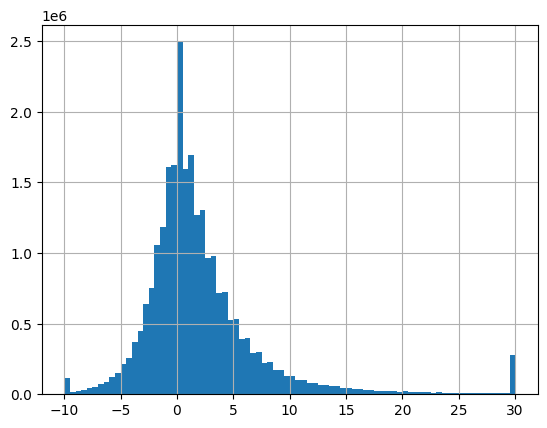

In [3]:
delays["arrival_delay_min"].clip(-10, 30).hist(bins=80)

In [4]:
otp = pd.read_sql("select * from v_route_otp_daily", engine)
otp.groupby("route_short_name")["on_time_rate"].mean().sort_values().head(20)

route_short_name
Red-N          0.003416
Red-S          0.051952
Green-S        0.076065
PH             0.249323
8AX            0.262944
CA             0.266900
PM             0.302222
Blue-S         0.312887
10T            0.328114
OX             0.328768
Orange-S       0.333583
Express 101    0.344417
46             0.349711
681            0.351390
8BX            0.353051
TBUS           0.353504
669            0.362490
373            0.366311
379            0.366667
Orange-N       0.374256
Name: on_time_rate, dtype: float64

In [5]:
# Delay progression along a trip: join stop_sequence and look at whether
# later stops in the same trip tend to be later-delayed than earlier ones.
prog = delays.groupby("stop_sequence")["arrival_delay_sec"].mean()
prog.head(30)

stop_sequence
0     1721.445532
1       96.914558
2      140.211556
3      144.900096
4      139.401180
5      141.023273
6      142.978683
7      143.265213
8      145.884589
9      146.303743
10     145.419031
11     147.597238
12     150.459769
13     152.134468
14     147.643882
15     152.146321
16     155.687240
17     156.443692
18     158.967754
19     158.334264
20     156.136960
21     153.605326
22     153.190389
23     157.990062
24     150.875726
25     145.437022
26     141.873250
27     142.496944
28     141.344150
29     135.581489
Name: arrival_delay_sec, dtype: float64